# 🎯 K-MEANS COMPLET - FROM SCRATCH vs SCIKIT-LEARN
## BATCH K OPTIMIZATION + FULL DATASET EVALUATION

## 1. 📦 IMPORTATION DES BIBLIOTHÈQUES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import math
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.cluster import KMeans as SklearnKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Calculs distances
from scipy.spatial.distance import cdist, pdist

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)

print("✅ Bibliothèques importées")

✅ Bibliothèques importées


## 2. 📂 CHARGEMENT DES DONNÉES

In [ ]:

print("📂 Chargement du dataset...")
try:
    df = pd.read_csv(r"C:\Users\Y A N I S\Desktop\set\output\unbalanced_clean.csv", sep=';')
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    
    columns_to_exclude = ['acq_date', 'X', 'Y', 'confidence', 'fire', 'type','tmax','TEB' ]
    
    
    print("\n🔍 VÉRIFICATION DES COLONNES:")
    print(f"   Total colonnes: {len(df.columns)}")
    print(f"   Colonnes à exclure: {len(columns_to_exclude)}")
    print(f"   'fire' dans colonnes exclues: {'fire' in columns_to_exclude}")
    
    # Features pour clustering
    feature_columns = [col for col in df.columns if col not in columns_to_exclude]
    
    print(f"\n📊 Features pour clustering ({len(feature_columns)}):")
    for i, feat in enumerate(feature_columns[:5]):
        print(f"   {i+1}. {feat}")
    if len(feature_columns) > 5:
        print(f"   ... et {len(feature_columns)-5} autres")
    
    # Préparation des données
    X = df[feature_columns].values
    y = df['fire'].values if 'fire' in df.columns else None
    
    print(f"\n✅ Dataset chargé: {X.shape[0]:,} lignes, {X.shape[1]} features")
    print(f"   Taille mémoire X: {X.nbytes / 1024 / 1024:.1f} MB")
    if y is not None:
        print(f"   Variable 'fire': {y.shape} (non utilisée pour clustering)")
    
except Exception as e:
    print(f"❌ Erreur chargement: {e}")
    # Création de données de test
    print("🔄 Création de données de test (10k points, 10 features)...")
    n_samples = 10000
    n_features = 10
    X = np.random.randn(n_samples, n_features) * 10 + np.random.randn(n_features) * 5
    y = None
    print(f"✅ Données de test: {X.shape[0]:,} lignes, {X.shape[1]} features")

📂 Chargement du dataset...

🔍 VÉRIFICATION DES COLONNES:
   Total colonnes: 44
   Colonnes à exclure: 8
   'fire' dans colonnes exclues: True

📊 Features pour clustering (36):
   1. country
   2. elevation_prep
   3. COARSE
   4. SAND
   5. SILT
   ... et 31 autres

✅ Dataset chargé: 583,222 lignes, 36 features
   Taille mémoire X: 160.2 MB
   Variable 'fire': (583222,) (non utilisée pour clustering)


## 3. 🎯 MÉTRIQUES RAPIDES POUR BATCH OPTIMIZATION

In [ ]:


def calculate_wcss_fast(X, labels, centroids):
    """WCSS rapide (utilise les centroïdes déjà calculés)"""
    wcss = 0.0
    for i, label in enumerate(np.unique(labels)):
        cluster_mask = (labels == label)
        if np.sum(cluster_mask) > 0:
            wcss += np.sum(np.linalg.norm(X[cluster_mask] - centroids[i], axis=1) ** 2)
    return wcss

def calculate_db_index_fast(X, labels, centroids):
    """Davies-Bouldin rapide (simplifié)"""
    k = len(centroids)
    if k < 2:
        return 1.0
    
    # Distances intra-cluster moyennes
    S = []
    for i in range(k):
        cluster_mask = (labels == i)
        if np.sum(cluster_mask) > 0:
            distances = np.linalg.norm(X[cluster_mask] - centroids[i], axis=1)
            S.append(np.mean(distances))
        else:
            S.append(0.0)
    
    # Distances inter-centroïdes
    M = cdist(centroids, centroids, metric='euclidean')
    np.fill_diagonal(M, np.inf)  # Éviter la division par 0
    
    # Calcul DB simplifié
    R = []
    for i in range(k):
        if S[i] > 0:
            ratios = [(S[i] + S[j]) / M[i, j] for j in range(k) if i != j]
            R.append(max(ratios) if ratios else 0)
        else:
            R.append(1.0)
    
    return np.mean(R) if R else 1.0

def calculate_cluster_balance_fast(labels, k):
    """Balance des clusters (variance des tailles)"""
    sizes = [np.sum(labels == i) for i in range(k)]
    if len(sizes) > 1:
        return np.std(sizes) / np.mean(sizes)
    return 0.0

def evaluate_k_fast(X, labels, centroids, k):
    """Évaluation rapide d'un clustering (pour optimisation batch)"""
    # 1. WCSS (log pour normalisation)
    wcss = calculate_wcss_fast(X, labels, centroids)
    wcss_term = np.log(max(wcss, 1e-10))
    
    # 2. DB Index
    db_term = calculate_db_index_fast(X, labels, centroids)
    
    # 3. Balance des clusters
    balance_term = calculate_cluster_balance_fast(labels, k)
    
    # 4. Bonus pour clusters non vides
    empty_clusters = sum([np.sum(labels == i) == 0 for i in range(k)])
    empty_penalty = empty_clusters * 0.2
    
    # Coût total (à minimiser)
    # Coefficients: 0.5 pour WCSS, 0.3 pour DB, 0.2 pour balance
    cost = 0.5 * wcss_term + 0.3 * db_term + 0.2 * balance_term + empty_penalty
    
    return cost, {
        'wcss': wcss,
        'db_index': db_term,
        'balance': balance_term,
        'empty_clusters': empty_clusters,
        'cost_components': [wcss_term, db_term, balance_term, empty_penalty]
    }

## 4. 🔧 K-MEANS FROM SCRATCH (VRAI VERSION BASIQUE)

In [ ]:


class KMeansScratchBasic:
    """Vrai K-Means from scratch basique comme dans ton code original"""
    
    def __init__(self, k=3, max_iter=100, random_state=None, noise_threshold=2.0):
        self.k = k
        self.max_iter = max_iter
        self.noise_threshold = noise_threshold
        if random_state is not None:
            np.random.seed(random_state)
    
    def fit(self, X):
        n_samples, n_features = X.shape
        
        print(f"   Initialisation aléatoire simple (vrai from scratch)...")
        
        # INITIALISATION ALÉATOIRE SIMPLE
        random_indices = np.random.choice(n_samples, self.k, replace=False)
        self.centroids = X[random_indices]
        
        
        self.inertia_history = []
        
        for iteration in range(self.max_iter):
            # Assignation : calcul des distances (méthode basique)
            distances = np.zeros((n_samples, self.k))
            for i in range(self.k):
                distances[:, i] = np.linalg.norm(X - self.centroids[i], axis=1)
            
            self.labels = np.argmin(distances, axis=1)
            
            # Calcul WCSS pour cette itération
            wcss = 0.0
            for i in range(self.k):
                cluster_points = X[self.labels == i]
                if len(cluster_points) > 0:
                    wcss += np.sum((cluster_points - self.centroids[i]) ** 2)
            self.inertia_history.append(wcss)
            
            # Recalcul des centroids (méthode basique)
            new_centroids = np.zeros((self.k, n_features))
            for i in range(self.k):
                cluster_points = X[self.labels == i]
                if len(cluster_points) > 0:
                    new_centroids[i] = cluster_points.mean(axis=0)
                else:
                    # Si cluster vide, on réinitialise aléatoirement
                    new_centroids[i] = X[np.random.randint(n_samples)]
            
            # Vérification convergence (simple)
            centroids_shift = np.linalg.norm(new_centroids - self.centroids)
            if centroids_shift < 1e-4:
                print(f"   ✅ Convergence à l'itération {iteration+1} (shift={centroids_shift:.6f})")
                break
            
            self.centroids = new_centroids
        
        # Détection du bruit
        self.detect_noise(X)
        
        # Final WCSS
        self.final_wcss = self.inertia_history[-1] if self.inertia_history else 0
        
        return self
    
    def detect_noise(self, X):
        """Détection simple des points de bruit"""
        n_samples = X.shape[0]
        
        # Calcul des distances au centroïde
        self.distances_to_centroid = np.zeros(n_samples)
        for i in range(n_samples):
            cluster_idx = self.labels[i]
            self.distances_to_centroid[i] = np.linalg.norm(X[i] - self.centroids[cluster_idx])
        
        # Calcul des statistiques par cluster
        self.cluster_stats = {}
        self.noise_mask = np.zeros(n_samples, dtype=bool)
        
        for i in range(self.k):
            cluster_mask = (self.labels == i)
            if np.sum(cluster_mask) > 0:
                cluster_distances = self.distances_to_centroid[cluster_mask]
                mean_dist = np.mean(cluster_distances)
                std_dist = np.std(cluster_distances)
                threshold = mean_dist + self.noise_threshold * std_dist
                
                self.cluster_stats[i] = {
                    'mean_distance': mean_dist,
                    'std_distance': std_dist,
                    'threshold': threshold,
                    'size': np.sum(cluster_mask)
                }
                
                # Marquer les points de bruit
                self.noise_mask[cluster_mask] = (cluster_distances > threshold)
        
        # Statistiques sur le bruit
        self.noise_stats = {
            'n_noise_points': np.sum(self.noise_mask),
            'noise_percentage': (np.sum(self.noise_mask) / n_samples) * 100,
            'noise_by_cluster': {}
        }
        
        # Bruit par cluster
        for i in range(self.k):
            cluster_mask = (self.labels == i)
            noise_in_cluster = np.sum(self.noise_mask & cluster_mask)
            total_in_cluster = np.sum(cluster_mask)
            if total_in_cluster > 0:
                self.noise_stats['noise_by_cluster'][i] = {
                    'n_noise': noise_in_cluster,
                    'total_points': total_in_cluster,
                    'percentage': (noise_in_cluster / total_in_cluster) * 100
                }
        
        # Créer des labels avec bruit marqué comme -1
        self.labels_with_noise = self.labels.copy()
        self.labels_with_noise[self.noise_mask] = -1
    
    def predict(self, X):
        """Prédiction pour de nouvelles données"""
        n_samples = X.shape[0]
        distances = np.zeros((n_samples, self.k))
        
        for i in range(self.k):
            distances[:, i] = np.linalg.norm(X - self.centroids[i], axis=1)
        
        labels = np.argmin(distances, axis=1)
        
        # Détection du bruit pour les nouvelles données
        distances_to_centroid = np.zeros(n_samples)
        for i in range(n_samples):
            cluster_idx = labels[i]
            distances_to_centroid[i] = np.linalg.norm(X[i] - self.centroids[cluster_idx])
        
        # Marquer le bruit
        noise_mask = np.zeros(n_samples, dtype=bool)
        for i in range(n_samples):
            cluster_idx = labels[i]
            if cluster_idx in self.cluster_stats:
                threshold = self.cluster_stats[cluster_idx]['threshold']
                if distances_to_centroid[i] > threshold:
                    noise_mask[i] = True
        
        labels_with_noise = labels.copy()
        labels_with_noise[noise_mask] = -1
        
        return labels_with_noise

## 5. 🔥 BATCH K OPTIMIZATION - OPTIMISATION RAPIDE

In [ ]:


def batch_k_optimization_scratch(X, k_range=(5, 12), sample_size=5000, 
                                n_runs=3, random_state=42):
    """Optimisation batch de k pour K-Means from scratch"""
    print("\n" + "="*70)
    print("🔢 BATCH K OPTIMIZATION - K-Means From Scratch")
    print("="*70)
    
    np.random.seed(random_state)
    n_total = X.shape[0]
    sample_size = min(sample_size, n_total)
    
    k_min, k_max = k_range
    k_values = list(range(k_min, k_max + 1))
    
    print(f"🔍 Configuration Batch Optimization:")
    print(f"   • Dataset total: {n_total:,} points")
    print(f"   • Échantillon: {sample_size:,} points")
    print(f"   • Plage k: {k_min}-{k_max} ({len(k_values)} valeurs)")
    print(f"   • Runs par k: {n_runs}")
    print(f"   • Métriques rapides: WCSS + DB + Balance")
    
    # Échantillon pour optimisation
    indices = np.random.choice(n_total, sample_size, replace=False)
    X_sample = X[indices]
    
    results = {}
    
    print(f"\n📊 Évaluation rapide des k...")
    pbar = tqdm(k_values, desc="Batch optimization")
    
    for k in pbar:
        costs = []
        metrics_list = []
        
        for run in range(n_runs):
            try:
                # K-Means rapide sur échantillon
                kmeans = KMeansScratchBasic(k=k, max_iter=50, random_state=random_state+run)
                kmeans.fit(X_sample)
                
                # Métriques rapides
                cost, metrics = evaluate_k_fast(
                    X_sample, kmeans.labels, kmeans.centroids, k
                )
                
                # Pénalité pour bruit élevé
                noise_pct = kmeans.noise_stats['noise_percentage']
                if noise_pct > 30:
                    cost += (noise_pct - 30) * 0.01
                
                costs.append(cost)
                metrics_list.append(metrics)
                
            except Exception as e:
                costs.append(float('inf'))
        
        # Prendre la meilleure run
        if costs and min(costs) < float('inf'):
            best_idx = np.argmin(costs)
            results[k] = {
                'cost': costs[best_idx],
                'metrics': metrics_list[best_idx],
                'all_costs': costs,
                'cost_mean': np.mean(costs),
                'cost_std': np.std(costs)
            }
        else:
            results[k] = {
                'cost': float('inf'),
                'metrics': None,
                'all_costs': [float('inf')] * n_runs,
                'cost_mean': float('inf'),
                'cost_std': 0.0
            }
    
    pbar.close()
    
    # Trouver le meilleur k
    valid_results = {k: v for k, v in results.items() if v['cost'] < float('inf')}
    
    if not valid_results:
        print("❌ Aucun k valide trouvé, utilisation du k par défaut (8)")
        best_k = 8
    else:
        best_k = min(valid_results.keys(), key=lambda k: valid_results[k]['cost'])
        best_cost = valid_results[best_k]['cost']
    
    # Visualisation des résultats
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # 1. Coût moyen par k
    costs = [results[k]['cost_mean'] if results[k]['cost_mean'] < float('inf') else np.nan 
             for k in k_values]
    valid_mask = ~np.isnan(costs)
    
    if np.any(valid_mask):
        axes[0, 0].plot(np.array(k_values)[valid_mask], np.array(costs)[valid_mask], 
                       'bo-', linewidth=2, markersize=8)
        axes[0, 0].scatter(best_k, results[best_k]['cost_mean'], 
                          color='red', s=200, zorder=5, 
                          label=f'k optimal={best_k}')
        axes[0, 0].set_xlabel('k')
        axes[0, 0].set_ylabel('Coût (moyenne)')
        axes[0, 0].set_title('Coût moyen par k')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Distribution des coûts (boxplot)
    if np.any(valid_mask):
        cost_data = [results[k]['all_costs'] for k in k_values if results[k]['cost'] < float('inf')]
        valid_k = [k for k in k_values if results[k]['cost'] < float('inf')]
        
        bp = axes[0, 1].boxplot(cost_data, positions=valid_k, widths=0.6)
        axes[0, 1].set_xlabel('k')
        axes[0, 1].set_ylabel('Distribution du coût')
        axes[0, 1].set_title('Distribution du coût (boxplot)')
        axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # 3. Composantes du coût pour le meilleur k
    if best_k in results and results[best_k]['metrics']:
        metrics = results[best_k]['metrics']
        if 'cost_components' in metrics:
            components = ['WCSS (log)', 'DB Index', 'Balance', 'Clusters vides']
            values = metrics['cost_components']
            
            colors = ['blue', 'orange', 'green', 'red']
            axes[1, 0].bar(components, values, color=colors, alpha=0.7, edgecolor='black')
            axes[1, 0].set_xlabel('Composante')
            axes[1, 0].set_ylabel('Valeur')
            axes[1, 0].set_title(f'Composantes du coût pour k={best_k}')
            axes[1, 0].tick_params(axis='x', rotation=45)
            axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # 4. Métriques par k
    if np.any(valid_mask):
        wcss_vals = []
        db_vals = []
        
        for k in k_values:
            if results[k]['metrics']:
                wcss_vals.append(results[k]['metrics']['wcss'])
                db_vals.append(results[k]['metrics']['db_index'])
            else:
                wcss_vals.append(np.nan)
                db_vals.append(np.nan)
        
        ax2 = axes[1, 1].twinx()
        line1, = axes[1, 1].plot(k_values, wcss_vals, 'b-', marker='o', 
                                label='WCSS', linewidth=2)
        line2, = ax2.plot(k_values, db_vals, 'r--', marker='s', 
                         label='DB Index', linewidth=2)
        
        axes[1, 1].set_xlabel('k')
        axes[1, 1].set_ylabel('WCSS', color='b')
        ax2.set_ylabel('DB Index', color='r')
        axes[1, 1].set_title('WCSS et DB Index par k')
        
        # Légende combinée
        lines = [line1, line2]
        labels = [l.get_label() for l in lines]
        axes[1, 1].legend(lines, labels, loc='upper left')
        
        axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle(f'Batch K Optimization - From Scratch\n{sample_size:,} points, {n_runs} runs par k', 
                fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Affichage des résultats
    print(f"\n📊 RÉSULTATS BATCH OPTIMIZATION:")
    print("-"*85)
    print(f"{'k':<5} {'Coût moyen':<15} {'Std':<10} {'WCSS':<15} {'DB Index':<15} {'Balance':<10}")
    print("-"*85)
    
    for k in k_values:
        if k in valid_results:
            metrics = results[k]['metrics']
            print(f"{k:<5} {results[k]['cost_mean']:<15.4f} {results[k]['cost_std']:<10.4f} "
                  f"{metrics['wcss']:<15.2f} {metrics['db_index']:<15.4f} {metrics['balance']:<10.4f}")
    print("-"*85)
    
    print(f"\n{'='*70}")
    print(f"🏆 MEILLEUR K TROUVÉ: {best_k}")
    print(f"   • Coût: {results[best_k]['cost_mean']:.4f}")
    print(f"   • WCSS: {results[best_k]['metrics']['wcss']:.2f}")
    print(f"   • DB Index: {results[best_k]['metrics']['db_index']:.4f}")
    print(f"   • Balance: {results[best_k]['metrics']['balance']:.4f}")
    print(f"{'='*70}")
    
    return best_k

def batch_k_optimization_sklearn(X, k_range=(5, 12), sample_size=5000, 
                                n_runs=3, random_state=42):
    """Optimisation batch de k pour K-Means scikit-learn"""
    print("\n" + "="*70)
    print("🔢 BATCH K OPTIMIZATION - K-Means Scikit-Learn")
    print("="*70)
    
    np.random.seed(random_state)
    n_total = X.shape[0]
    sample_size = min(sample_size, n_total)
    
    k_min, k_max = k_range
    k_values = list(range(k_min, k_max + 1))
    
    print(f"🔍 Configuration Batch Optimization:")
    print(f"   • Dataset total: {n_total:,} points")
    print(f"   • Échantillon: {sample_size:,} points")
    print(f"   • Plage k: {k_min}-{k_max} ({len(k_values)} valeurs)")
    print(f"   • Runs par k: {n_runs}")
    print(f"   • Métriques rapides: WCSS + DB + Balance")
    
    # Échantillon pour optimisation
    indices = np.random.choice(n_total, sample_size, replace=False)
    X_sample = X[indices]
    
    results = {}
    
    print(f"\n📊 Évaluation rapide des k...")
    pbar = tqdm(k_values, desc="Batch optimization")
    
    for k in pbar:
        costs = []
        metrics_list = []
        
        for run in range(n_runs):
            try:
                # K-Means scikit-learn rapide
                kmeans = SklearnKMeans(
                    n_clusters=k,
                    init='k-means++',
                    n_init=1,  # 1 init pour la vitesse
                    max_iter=100,
                    random_state=random_state+run
                )
                labels = kmeans.fit_predict(X_sample)
                
                # Métriques rapides
                cost, metrics = evaluate_k_fast(
                    X_sample, labels, kmeans.cluster_centers_, k
                )
                
                # Détection rapide du bruit
                noise_mask, _, noise_stats = detect_noise_points(
                    X_sample, labels, kmeans.cluster_centers_, noise_threshold=2.0
                )
                noise_pct = noise_stats['noise_percentage']
                if noise_pct > 30:
                    cost += (noise_pct - 30) * 0.01
                
                costs.append(cost)
                metrics_list.append(metrics)
                
            except Exception as e:
                costs.append(float('inf'))
        
        # Prendre la meilleure run
        if costs and min(costs) < float('inf'):
            best_idx = np.argmin(costs)
            results[k] = {
                'cost': costs[best_idx],
                'metrics': metrics_list[best_idx],
                'all_costs': costs,
                'cost_mean': np.mean(costs),
                'cost_std': np.std(costs)
            }
        else:
            results[k] = {
                'cost': float('inf'),
                'metrics': None,
                'all_costs': [float('inf')] * n_runs,
                'cost_mean': float('inf'),
                'cost_std': 0.0
            }
    
    pbar.close()
    
    # Trouver le meilleur k
    valid_results = {k: v for k, v in results.items() if v['cost'] < float('inf')}
    
    if not valid_results:
        print("❌ Aucun k valide trouvé, utilisation du k par défaut (8)")
        best_k = 8
    else:
        best_k = min(valid_results.keys(), key=lambda k: valid_results[k]['cost'])
        best_cost = valid_results[best_k]['cost']
    
    # Visualisation (similaire à from scratch)
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # 1. Coût moyen par k
    costs = [results[k]['cost_mean'] if results[k]['cost_mean'] < float('inf') else np.nan 
             for k in k_values]
    valid_mask = ~np.isnan(costs)
    
    if np.any(valid_mask):
        axes[0, 0].plot(np.array(k_values)[valid_mask], np.array(costs)[valid_mask], 
                       'ro-', linewidth=2, markersize=8)
        axes[0, 0].scatter(best_k, results[best_k]['cost_mean'], 
                          color='green', s=200, zorder=5, 
                          label=f'k optimal={best_k}')
        axes[0, 0].set_xlabel('k')
        axes[0, 0].set_ylabel('Coût (moyenne)')
        axes[0, 0].set_title('Coût moyen par k')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Distribution des coûts
    if np.any(valid_mask):
        cost_data = [results[k]['all_costs'] for k in k_values if results[k]['cost'] < float('inf')]
        valid_k = [k for k in k_values if results[k]['cost'] < float('inf')]
        
        bp = axes[0, 1].boxplot(cost_data, positions=valid_k, widths=0.6)
        axes[0, 1].set_xlabel('k')
        axes[0, 1].set_ylabel('Distribution du coût')
        axes[0, 1].set_title('Distribution du coût (boxplot)')
        axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # 3. Silhouette rapide par k (optionnel)
    if np.any(valid_mask):
        silhouette_vals = []
        for k in k_values:
            if results[k]['metrics']:
                # Calcul silhouette simplifié
                try:
                    kmeans_test = SklearnKMeans(n_clusters=k, random_state=42, n_init=1)
                    labels_test = kmeans_test.fit_predict(X_sample[:min(2000, sample_size)])
                    if len(np.unique(labels_test)) > 1:
                        sil = silhouette_score(X_sample[:min(2000, sample_size)], labels_test)
                        silhouette_vals.append(sil)
                    else:
                        silhouette_vals.append(0)
                except:
                    silhouette_vals.append(0)
            else:
                silhouette_vals.append(np.nan)
        
        if any(not np.isnan(v) for v in silhouette_vals):
            axes[1, 0].plot(k_values, silhouette_vals, 'g-', marker='^', 
                           linewidth=2, markersize=8)
            axes[1, 0].set_xlabel('k')
            axes[1, 0].set_ylabel('Silhouette Score')
            axes[1, 0].set_title('Silhouette Score par k')
            axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Comparaison WCSS et DB
    if np.any(valid_mask):
        wcss_vals = []
        db_vals = []
        
        for k in k_values:
            if results[k]['metrics']:
                wcss_vals.append(results[k]['metrics']['wcss'])
                db_vals.append(results[k]['metrics']['db_index'])
            else:
                wcss_vals.append(np.nan)
                db_vals.append(np.nan)
        
        ax2 = axes[1, 1].twinx()
        line1, = axes[1, 1].plot(k_values, wcss_vals, 'b-', marker='o', 
                                label='WCSS', linewidth=2)
        line2, = ax2.plot(k_values, db_vals, 'r--', marker='s', 
                         label='DB Index', linewidth=2)
        
        axes[1, 1].set_xlabel('k')
        axes[1, 1].set_ylabel('WCSS', color='b')
        ax2.set_ylabel('DB Index', color='r')
        axes[1, 1].set_title('WCSS et DB Index par k')
        
        lines = [line1, line2]
        labels = [l.get_label() for l in lines]
        axes[1, 1].legend(lines, labels, loc='upper left')
        axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle(f'Batch K Optimization - Scikit-Learn\n{sample_size:,} points, {n_runs} runs par k', 
                fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Affichage des résultats
    print(f"\n📊 RÉSULTATS BATCH OPTIMIZATION:")
    print("-"*85)
    print(f"{'k':<5} {'Coût moyen':<15} {'Std':<10} {'WCSS':<15} {'DB Index':<15} {'Balance':<10}")
    print("-"*85)
    
    for k in k_values:
        if k in valid_results:
            metrics = results[k]['metrics']
            print(f"{k:<5} {results[k]['cost_mean']:<15.4f} {results[k]['cost_std']:<10.4f} "
                  f"{metrics['wcss']:<15.2f} {metrics['db_index']:<15.4f} {metrics['balance']:<10.4f}")
    print("-"*85)
    
    print(f"\n{'='*70}")
    print(f"🏆 MEILLEUR K TROUVÉ: {best_k}")
    print(f"   • Coût: {results[best_k]['cost_mean']:.4f}")
    print(f"   • WCSS: {results[best_k]['metrics']['wcss']:.2f}")
    print(f"   • DB Index: {results[best_k]['metrics']['db_index']:.4f}")
    print(f"   • Balance: {results[best_k]['metrics']['balance']:.4f}")
    print(f"{'='*70}")
    
    return best_k

## 6. 📊 MÉTRIQUES COMPLÈTES POUR ÉVALUATION FINALE

In [6]:
# ==========================
# MÉTRIQUES COMPLÈTES POUR ÉVALUATION FINALE
# ==========================

def calculate_wcss_full(X, labels):
    """WCSS calculé sur TOUS les points"""
    unique_labels = np.unique(labels)
    wcss = 0.0
    for label in unique_labels:
        cluster_points = X[labels == label]
        if len(cluster_points) > 0:
            centroid = cluster_points.mean(axis=0)
            wcss += np.sum((cluster_points - centroid) ** 2)
    return wcss

def calculate_dunn_index_full(X, labels):
    """Dunn Index calculé sur tout le dataset"""
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        return 0.0
    
    # 1. Calcul des centroids
    centroids = []
    intra_cluster_max = []
    
    for label in unique_labels:
        cluster_points = X[labels == label]
        if len(cluster_points) > 0:
            centroid = cluster_points.mean(axis=0)
            centroids.append(centroid)
            
            # Distance maximale intra-cluster
            if len(cluster_points) > 1:
                distances = pdist(cluster_points, metric='euclidean')
                intra_cluster_max.append(np.max(distances))
            else:
                intra_cluster_max.append(0.0)
        else:
            centroids.append(np.zeros(X.shape[1]))
            intra_cluster_max.append(0.0)
    
    centroids = np.array(centroids)
    
    # 2. Distance minimale inter-cluster
    inter_cluster_dist = cdist(centroids, centroids, metric='euclidean')
    np.fill_diagonal(inter_cluster_dist, np.inf)
    min_inter = np.min(inter_cluster_dist)
    
    # 3. Distance maximale intra-cluster
    max_intra = np.max(intra_cluster_max)
    
    if max_intra == 0:
        return 0.0
    
    return min_inter / max_intra

def detect_noise_points(X, labels, centroids, noise_threshold=2.0):
    """Détection des points de bruit"""
    n_samples = X.shape[0]
    
    # Calcul des distances de chaque point à son centroïde
    distances_to_centroid = np.zeros(n_samples)
    for i in range(n_samples):
        cluster_idx = labels[i]
        distances_to_centroid[i] = np.linalg.norm(X[i] - centroids[cluster_idx])
    
    # Calcul des statistiques par cluster
    unique_labels = np.unique(labels)
    cluster_stats = {}
    
    for label in unique_labels:
        cluster_mask = (labels == label)
        if np.sum(cluster_mask) > 0:
            cluster_distances = distances_to_centroid[cluster_mask]
            mean_dist = np.mean(cluster_distances)
            std_dist = np.std(cluster_distances)
            cluster_stats[label] = {
                'mean_distance': mean_dist,
                'std_distance': std_dist,
                'threshold': mean_dist + noise_threshold * std_dist
            }
    
    # Identification des points de bruit
    noise_mask = np.zeros(n_samples, dtype=bool)
    for i in range(n_samples):
        cluster_idx = labels[i]
        dist = distances_to_centroid[i]
        if dist > cluster_stats[cluster_idx]['threshold']:
            noise_mask[i] = True
    
    # Statistiques sur le bruit
    noise_stats = {
        'n_noise_points': np.sum(noise_mask),
        'noise_percentage': (np.sum(noise_mask) / n_samples) * 100,
        'noise_by_cluster': {},
        'cluster_stats': cluster_stats
    }
    
    # Bruit par cluster
    for label in unique_labels:
        cluster_mask = (labels == label)
        noise_in_cluster = np.sum(noise_mask & cluster_mask)
        total_in_cluster = np.sum(cluster_mask)
        if total_in_cluster > 0:
            noise_stats['noise_by_cluster'][label] = {
                'n_noise': noise_in_cluster,
                'total_points': total_in_cluster,
                'percentage': (noise_in_cluster / total_in_cluster) * 100
            }
    
    return noise_mask, distances_to_centroid, noise_stats

def evaluate_all_metrics_full(X, labels, centroids=None, model_name=""):
    """Calcule les 5 métriques complètes sur TOUT le dataset"""
    print(f"\n{'='*70}")
    print(f"📊 ÉVALUATION COMPLÈTE - {model_name}")
    print(f"{'='*70}")
    print(f"Dataset: {X.shape[0]:,} points, {X.shape[1]} features")
    print(f"Clusters: {len(np.unique(labels))}")
    
    metrics = {}
    
    # 1. WCSS
    print("\n1️⃣  WCSS (Within-Cluster Sum of Squares)...")
    start = time.time()
    metrics['wcss'] = calculate_wcss_full(X, labels)
    print(f"   ✅ WCSS = {metrics['wcss']:.2f} (temps: {time.time()-start:.2f}s)")
    
    # 2. Silhouette
    print("\n2️⃣  Silhouette Score...")
    start = time.time()
    metrics['silhouette'] = silhouette_score(X, labels)
    print(f"   ✅ Silhouette = {metrics['silhouette']:.4f} (temps: {time.time()-start:.2f}s)")
    
    # 3. Davies-Bouldin
    print("\n3️⃣  Davies-Bouldin Index...")
    start = time.time()
    metrics['davies_bouldin'] = davies_bouldin_score(X, labels)
    print(f"   ✅ Davies-Bouldin = {metrics['davies_bouldin']:.4f} (temps: {time.time()-start:.2f}s)")
    
    # 4. Calinski-Harabasz
    print("\n4️⃣  Calinski-Harabasz Index...")
    start = time.time()
    metrics['calinski_harabasz'] = calinski_harabasz_score(X, labels)
    print(f"   ✅ Calinski-Harabasz = {metrics['calinski_harabasz']:.2f} (temps: {time.time()-start:.2f}s)")
    
    # 5. Dunn Index
    print("\n5️⃣  Dunn Index...")
    start = time.time()
    metrics['dunn_index'] = calculate_dunn_index_full(X, labels)
    print(f"   ✅ Dunn Index = {metrics['dunn_index']:.4f} (temps: {time.time()-start:.2f}s)")
    
    # 6. Détection du bruit
    if centroids is not None:
        print("\n6️⃣  Détection des points de bruit...")
        start = time.time()
        noise_mask, distances_to_centroid, noise_stats = detect_noise_points(
            X, labels, centroids, noise_threshold=2.0
        )
        metrics['noise_stats'] = noise_stats
        metrics['noise_mask'] = noise_mask
        metrics['distances_to_centroid'] = distances_to_centroid
        
        print(f"   ✅ Bruit détecté: {noise_stats['n_noise_points']:,} points ({noise_stats['noise_percentage']:.2f}%)")
        print(f"   ✅ Temps détection bruit: {time.time()-start:.2f}s")
    
    # Interprétation
    print(f"\n{'='*70}")
    print("📊 INTERPRÉTATION DES MÉTRIQUES")
    print(f"{'='*70}")
    
    # Silhouette
    silhouette_val = metrics['silhouette']
    if silhouette_val > 0.7:
        silhouette_interpretation = "✅ Excellent clustering"
    elif silhouette_val > 0.5:
        silhouette_interpretation = "✅ Bon clustering"
    elif silhouette_val > 0.25:
        silhouette_interpretation = "⚠️  Clustering moyen"
    else:
        silhouette_interpretation = "❌ Faible clustering"
    
    # Davies-Bouldin
    davies_val = metrics['davies_bouldin']
    if davies_val < 0.5:
        davies_interpretation = "✅ Excellent"
    elif davies_val < 1.0:
        davies_interpretation = "✅ Bon"
    else:
        davies_interpretation = "⚠️  Moyen"
    
    print(f"   Silhouette ({silhouette_val:.4f}): {silhouette_interpretation}")
    print(f"   Davies-Bouldin ({davies_val:.4f}): {davies_interpretation}")
    print(f"   Calinski-Harabasz: {metrics['calinski_harabasz']:.2f} (plus élevé = mieux)")
    print(f"   Dunn Index: {metrics['dunn_index']:.4f} (plus élevé = mieux)")
    
    if centroids is not None and 'noise_stats' in metrics:
        noise_pct = metrics['noise_stats']['noise_percentage']
        if noise_pct < 5:
            print(f"   Bruit ({noise_pct:.2f}%): ✅ Faible niveau de bruit")
        elif noise_pct < 15:
            print(f"   Bruit ({noise_pct:.2f}%): ⚠️  Niveau modéré de bruit")
        else:
            print(f"   Bruit ({noise_pct:.2f}%): ❌ Fort niveau de bruit")
    
    return metrics

## 7. 📊 VISUALISATIONS DES CLUSTERS

In [ ]:
# ==========================
# FONCTIONS DE VISUALISATION
# ==========================

def visualize_clusters_basic(X, labels, noise_mask=None, centroids=None, 
                            title="Visualisation PCA"):
    """Visualisation 2D simple des clusters avec PCA"""
    
    # PCA pour visualisation
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    plt.figure(figsize=(10, 8))
    
    if noise_mask is not None and np.any(noise_mask):
        # Points normaux
        normal_indices = ~noise_mask
        scatter_normal = plt.scatter(X_pca[normal_indices, 0], X_pca[normal_indices, 1], 
                                     c=labels[normal_indices], cmap='tab20', 
                                     alpha=0.6, s=10, edgecolors='none',
                                     label='Points normaux')
        
        # Points de bruit
        scatter_noise = plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], 
                                    c='black', alpha=0.3, s=5, 
                                    label='Points de bruit')
        
        plt.legend()
    else:
        # Tous les points
        scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                             c=labels, cmap='tab20', 
                             alpha=0.6, s=10, edgecolors='none')
        plt.colorbar(scatter, label='Cluster')
    
    # Centroïdes
    if centroids is not None:
        centroids_pca = pca.transform(centroids)
        plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                   c='red', marker='X', s=200, 
                   label='Centroids', edgecolors='black', linewidths=1.5)
        plt.legend()
    
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return X_pca

def plot_cluster_distribution(labels, noise_mask=None, title="Distribution des Clusters"):
    """Histogramme simple de la distribution des points par cluster"""
    
    if noise_mask is not None:
        labels_with_noise = labels.copy()
        labels_with_noise[noise_mask] = -1
        unique_labels = np.unique(labels_with_noise)
    else:
        labels_with_noise = labels
        unique_labels = np.unique(labels)
    
    # Compter les points
    counts = []
    labels_list = []
    
    for label in unique_labels:
        if label == -1:
            label_name = 'Bruit'
            color = 'black'
        else:
            label_name = f'Cluster {label}'
            color = plt.cm.tab20(label % 20)
        
        count = np.sum(labels_with_noise == label)
        counts.append(count)
        labels_list.append(label_name)
    
    # Trier
    sorted_indices = np.argsort([-1 if 'Bruit' in l else int(l.split()[-1]) for l in labels_list])
    counts = [counts[i] for i in sorted_indices]
    labels_list = [labels_list[i] for i in sorted_indices]
    
    # Créer le graphique
    plt.figure(figsize=(12, 6))
    colors = ['black' if 'Bruit' in l else plt.cm.tab20(int(l.split()[-1]) % 20) for l in labels_list]
    
    bars = plt.bar(labels_list, counts, color=colors, 
                   edgecolor='black', alpha=0.8)
    
    plt.xlabel('Cluster')
    plt.ylabel('Nombre de Points')
    plt.title(title)
    plt.grid(True, alpha=0.3, axis='y')
    plt.xticks(rotation=45, ha='right')
    
    # Ajouter les nombres
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + max(counts)*0.01,
                f'{count:,}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Statistiques
    print(f"📊 STATISTIQUES CLUSTERS:")
    if noise_mask is not None:
        noise_count = np.sum(noise_mask)
        print(f"   Points de bruit: {noise_count:,} ({noise_count/len(labels)*100:.2f}%)")
    
    cluster_counts = [c for c, l in zip(counts, labels_list) if 'Bruit' not in l]
    if cluster_counts:
        print(f"   Nombre de clusters: {len(cluster_counts)}")
        print(f"   Points par cluster: min={min(cluster_counts):,}, max={max(cluster_counts):,}")
        print(f"   Ratio min/max: {min(cluster_counts)/max(cluster_counts):.2%}")

def compare_metrics_simple(metrics_scratch, metrics_sklearn):
    """Comparaison simple des métriques"""
    
    print("\n📊 COMPARAISON DES MÉTRIQUES:")
    print("-"*85)
    print(f"{'Métrique':<25} {'From Scratch':<20} {'Scikit-Learn':<20} {'Différence':<15} {'Meilleur':<10}")
    print("-"*85)
    
    # Métriques principales
    metric_configs = [
        ('WCSS', 'wcss', 2, '↓'),
        ('Silhouette', 'silhouette', 4, '↑'),
        ('Davies-Bouldin', 'davies_bouldin', 4, '↓'),
        ('Calinski-Harabasz', 'calinski_harabasz', 2, '↑'),
        ('Dunn Index', 'dunn_index', 4, '↑'),
    ]
    
    for display_name, metric_name, decimals, direction in metric_configs:
        val_scratch = metrics_scratch[metric_name]
        val_sklearn = metrics_sklearn[metric_name]
        diff = abs(val_scratch - val_sklearn)
        
        
        if direction == '↑':  
            best = 'Scratch' if val_scratch > val_sklearn else 'Sklearn'
            if val_scratch == val_sklearn:
                best = 'Égal'
        else:  
            best = 'Scratch' if val_scratch < val_sklearn else 'Sklearn'
            if val_scratch == val_sklearn:
                best = 'Égal'
        
        if decimals == 2:
            print(f"{display_name:<25} {val_scratch:<20.2f} {val_sklearn:<20.2f} {diff:<15.2f} {best:<10}")
        else:
            print(f"{display_name:<25} {val_scratch:<20.4f} {val_sklearn:<20.4f} {diff:<15.4f} {best:<10}")
    
    print("-"*85)

## 8. 🚀 EXÉCUTION PRINCIPALE AVEC BATCH OPTIMIZATION

In [8]:
# ==========================
# EXÉCUTION COMPLÈTE AVEC BATCH OPTIMIZATION
# ==========================

def run_complete_analysis_batch():
    """Exécution complète avec batch optimization (5-12)"""
    
    print("="*80)
    print("         🚀 ANALYSE COMPLÈTE K-MEANS")
    print("         BATCH OPTIMIZATION (k: 5-12)")
    print("="*80)
    
    print(f"\n📊 Dataset: {X.shape[0]:,} points, {X.shape[1]} features")
    
    results = {}
    
    # ============================================
    # PARTIE 1: K-MEANS FROM SCRATCH
    # ============================================
    print("\n" + "="*80)
    print("1️⃣  K-MEANS FROM SCRATCH (VRAI VERSION BASIQUE)")
    print("="*80)
    
    # Étape 1: Batch Optimization rapide
    print("\n🔍 ÉTAPE 1: Batch Optimization rapide (5-12)")
    
    n_total = X.shape[0]
    
    k_scratch = batch_k_optimization_scratch(
        X, 
        k_range=(5, 12),
        sample_size=min(5000, n_total),
        n_runs=3,
        random_state=42
    )
    
    # Étape 2: Entraînement FINAL sur TOUT le dataset
    print(f"\n🎯 ÉTAPE 2: ENTRAÎNEMENT FINAL avec k={k_scratch} sur TOUT le dataset")
    print(f"   ({n_total:,} points, {X.shape[1]} features)")
    print("   Vrai K-Means from scratch (version complète)...")
    
    start_time = time.time()
    kmeans_scratch = KMeansScratchBasic(
        k=k_scratch, 
        max_iter=200, 
        random_state=42,
        noise_threshold=2.0
    )
    kmeans_scratch.fit(X)
    time_scratch = time.time() - start_time
    
    print(f"✅ Entraînement FINAL terminé en {time_scratch:.2f} secondes")
    print(f"   Final WCSS: {kmeans_scratch.final_wcss:.2f}")
    print(f"   Points de bruit: {kmeans_scratch.noise_stats['n_noise_points']:,} "
          f"({kmeans_scratch.noise_stats['noise_percentage']:.2f}%)")
    
    # Étape 3: MÉTRIQUES COMPLÈTES sur TOUT le dataset
    print("\n📊 ÉTAPE 3: MÉTRIQUES COMPLÈTES sur 100% du dataset")
    metrics_scratch = evaluate_all_metrics_full(
        X, 
        kmeans_scratch.labels, 
        kmeans_scratch.centroids,
        "K-Means From Scratch (Batch Optimized)"
    )
    metrics_scratch['training_time'] = time_scratch
    
    # Étape 4: Visualisation
    print("\n🎨 ÉTAPE 4: Visualisation des résultats")
    
    X_pca_scratch = visualize_clusters_basic(
        X, 
        kmeans_scratch.labels_with_noise,
        kmeans_scratch.noise_mask,
        kmeans_scratch.centroids,
        title=f"K-Means From Scratch (k={k_scratch})"
    )
    
    plot_cluster_distribution(
        kmeans_scratch.labels,
        kmeans_scratch.noise_mask,
        title=f"Distribution - From Scratch (k={k_scratch})"
    )
    
    # Stockage des résultats
    results['scratch'] = {
        'model': kmeans_scratch,
        'metrics': metrics_scratch,
        'k': k_scratch,
        'time': time_scratch,
        'labels': kmeans_scratch.labels.copy(),
        'labels_with_noise': kmeans_scratch.labels_with_noise.copy(),
        'noise_mask': kmeans_scratch.noise_mask.copy(),
        'noise_stats': kmeans_scratch.noise_stats.copy(),
        'centroids': kmeans_scratch.centroids.copy()
    }
    
    # ============================================
    # PARTIE 2: K-MEANS SCIKIT-LEARN
    # ============================================
    print("\n" + "="*80)
    print("2️⃣  K-MEANS SCIKIT-LEARN (OPTIMISÉ)")
    print("="*80)
    
    # Étape 1: Batch Optimization rapide
    print("\n🔍 ÉTAPE 1: Batch Optimization rapide (5-12)")
    
    k_sklearn = batch_k_optimization_sklearn(
        X, 
        k_range=(5, 12),
        sample_size=min(8000, n_total),
        n_runs=3,
        random_state=42
    )
    
    # Étape 2: Entraînement FINAL sur TOUT le dataset
    print(f"\n🎯 ÉTAPE 2: ENTRAÎNEMENT FINAL avec k={k_sklearn} sur TOUT le dataset")
    print(f"   ({n_total:,} points, {X.shape[1]} features)")
    print("   Scikit-Learn avec k-means++ (version complète)...")
    
    start_time = time.time()
    kmeans_sklearn = SklearnKMeans(
        n_clusters=k_sklearn, 
        random_state=42, 
        n_init=5,
        init='k-means++',
        max_iter=300
    )
    kmeans_sklearn.fit(X)
    time_sklearn = time.time() - start_time
    
    print(f"✅ Entraînement FINAL terminé en {time_sklearn:.2f} secondes")
    print(f"   Inertia: {kmeans_sklearn.inertia_:.2f}")
    
    # Détection du bruit
    noise_mask_sklearn, _, noise_stats_sklearn = detect_noise_points(
        X, kmeans_sklearn.labels_, kmeans_sklearn.cluster_centers_, noise_threshold=2.0
    )
    
    print(f"   Points de bruit: {noise_stats_sklearn['n_noise_points']:,} "
          f"({noise_stats_sklearn['noise_percentage']:.2f}%)")
    
    labels_with_noise_sklearn = kmeans_sklearn.labels_.copy()
    labels_with_noise_sklearn[noise_mask_sklearn] = -1
    
    # Étape 3: MÉTRIQUES COMPLÈTES sur TOUT le dataset
    print("\n📊 ÉTAPE 3: MÉTRIQUES COMPLÈTES sur 100% du dataset")
    metrics_sklearn = evaluate_all_metrics_full(
        X, 
        kmeans_sklearn.labels_, 
        kmeans_sklearn.cluster_centers_,
        "K-Means Scikit-Learn (Batch Optimized)"
    )
    metrics_sklearn['training_time'] = time_sklearn
    
    # Étape 4: Visualisation
    print("\n🎨 ÉTAPE 4: Visualisation des résultats")
    
    X_pca_sklearn = visualize_clusters_basic(
        X, 
        labels_with_noise_sklearn,
        noise_mask_sklearn,
        kmeans_sklearn.cluster_centers_,
        title=f"K-Means Scikit-Learn (k={k_sklearn})"
    )
    
    plot_cluster_distribution(
        kmeans_sklearn.labels_,
        noise_mask_sklearn,
        title=f"Distribution - Scikit-Learn (k={k_sklearn})"
    )
    
    # Stockage des résultats
    results['sklearn'] = {
        'model': kmeans_sklearn,
        'metrics': metrics_sklearn,
        'k': k_sklearn,
        'time': time_sklearn,
        'labels': kmeans_sklearn.labels_.copy(),
        'labels_with_noise': labels_with_noise_sklearn.copy(),
        'noise_mask': noise_mask_sklearn.copy(),
        'noise_stats': noise_stats_sklearn.copy(),
        'centroids': kmeans_sklearn.cluster_centers_.copy()
    }
    
    # ============================================
    # PARTIE 3: COMPARAISON DÉTAILLÉE
    # ============================================
    print("\n" + "="*80)
    print("3️⃣  COMPARAISON DÉTAILLÉE")
    print("="*80)
    
    compare_metrics_simple(results['scratch']['metrics'], results['sklearn']['metrics'])
    
    # Tableau de comparaison
    print("\n📊 TABLEAU COMPARATIF SUPPLEMENTAIRE:")
    print("-"*85)
    print(f"{'Métrique':<25} {'From Scratch':<20} {'Scikit-Learn':<20}")
    print("-"*85)
    
    noise_pct_scratch = results['scratch']['noise_stats']['noise_percentage']
    noise_pct_sklearn = results['sklearn']['noise_stats']['noise_percentage']
    
    print(f"{'% Bruit':<25} {noise_pct_scratch:<20.2f}% {noise_pct_sklearn:<20.2f}%")
    print(f"{'Points bruit':<25} {results['scratch']['noise_stats']['n_noise_points']:<20,} "
          f"{results['sklearn']['noise_stats']['n_noise_points']:<20,}")
    print(f"{'Temps (s)':<25} {time_scratch:<20.2f} {time_sklearn:<20.2f}")
    print(f"{'k optimal':<25} {k_scratch:<20} {k_sklearn:<20}")
    print(f"{'Méthode init':<25} {'Aléatoire':<20} {'k-means++':<20}")
    print("-"*85)
    
    # Visualisation côte à côte
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    axes[0, 0].scatter(X_pca_scratch[:, 0], X_pca_scratch[:, 1], 
                       c=results['scratch']['labels_with_noise'], 
                       cmap='tab20', alpha=0.5, s=5)
    axes[0, 0].set_xlabel('PCA Component 1')
    axes[0, 0].set_ylabel('PCA Component 2')
    axes[0, 0].set_title(f'From Scratch (k={k_scratch})\nBruit: {noise_pct_scratch:.1f}%')
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].scatter(X_pca_sklearn[:, 0], X_pca_sklearn[:, 1], 
                       c=results['sklearn']['labels_with_noise'], 
                       cmap='tab20', alpha=0.5, s=5)
    axes[0, 1].set_xlabel('PCA Component 1')
    axes[0, 1].set_ylabel('PCA Component 2')
    axes[0, 1].set_title(f'Scikit-Learn (k={k_sklearn})\nBruit: {noise_pct_sklearn:.1f}%')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Comparaison métriques clés
    metric_names = ['Silhouette', 'Davies-Bouldin']
    scratch_vals = [results['scratch']['metrics']['silhouette'], 
                    results['scratch']['metrics']['davies_bouldin']]
    sklearn_vals = [results['sklearn']['metrics']['silhouette'], 
                    results['sklearn']['metrics']['davies_bouldin']]
    
    x = np.arange(len(metric_names))
    width = 0.35
    
    axes[1, 0].bar(x - width/2, scratch_vals, width, label='From Scratch', 
                   color='blue', alpha=0.7)
    axes[1, 0].bar(x + width/2, sklearn_vals, width, label='Scikit-Learn', 
                   color='red', alpha=0.7)
    axes[1, 0].set_xlabel('Métrique')
    axes[1, 0].set_ylabel('Valeur')
    axes[1, 0].set_title('Comparaison Métriques Clés')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(metric_names)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Temps et bruit
    categories = ['Temps (s)', '% Bruit']
    scratch_values = [time_scratch, noise_pct_scratch]
    sklearn_values = [time_sklearn, noise_pct_sklearn]
    
    x = np.arange(len(categories))
    axes[1, 1].bar(x - width/2, scratch_values, width, label='From Scratch', 
                   color='blue', alpha=0.7)
    axes[1, 1].bar(x + width/2, sklearn_values, width, label='Scikit-Learn', 
                   color='red', alpha=0.7)
    axes[1, 1].set_xlabel('Catégorie')
    axes[1, 1].set_ylabel('Valeur')
    axes[1, 1].set_title('Temps d\'exécution et Bruit')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(categories)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle('Comparaison: From Scratch vs Scikit-Learn (Batch Optimization)', 
                fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Similarité entre les clustering
    if len(results['scratch']['labels']) == len(results['sklearn']['labels']):
        similarity = adjusted_rand_score(results['scratch']['labels'], 
                                        results['sklearn']['labels'])
        
        print(f"\n🔗 SIMILARITÉ ENTRE LES DEUX CLUSTERING:")
        print(f"   Adjusted Rand Index: {similarity:.4f}")
        print(f"   • 1.0 = clusters identiques")
        print(f"   • 0.0 = clusters indépendants")
        
        if similarity > 0.8:
            print(f"   ✅ Les deux algorithmes produisent des clusters très similaires")
        elif similarity > 0.5:
            print(f"   ⚠️  Les clusters sont modérément similaires")
        else:
            print(f"   ❌ Les clusters diffèrent significativement")
    
    # Recommandation finale
    print(f"\n💡 RECOMMANDATION FINALE:")
    print(f"   • Batch Optimization: test rapide sur échantillon (5-12)")
    print(f"   • Entraînement final: métriques complètes sur 100% du dataset")
    print(f"   • Différence silhouette: {results['sklearn']['metrics']['silhouette'] - results['scratch']['metrics']['silhouette']:.4f}")
    print(f"   • Gain de temps: {time_scratch - time_sklearn:.2f}s")
    
    if results['sklearn']['metrics']['silhouette'] > results['scratch']['metrics']['silhouette']:
        print(f"   🏆 Scikit-Learn est meilleur en qualité (silhouette plus élevée)")
    else:
        print(f"   🏆 From Scratch est meilleur en qualité (silhouette plus élevée)")
    
    return results

## 9. 🚀 LANCEMENT DE L'ANALYSE AVEC BATCH OPTIMIZATION

🚀 Lancement de l'analyse avec Batch Optimization...
   Étape 1: Test rapide des k (5-12) sur échantillon
   Étape 2: Entraînement final avec meilleur k sur 100% du dataset
   Étape 3: Métriques complètes sur dataset complet
         🚀 ANALYSE COMPLÈTE K-MEANS
         BATCH OPTIMIZATION (k: 5-12)

📊 Dataset: 583,222 points, 36 features

1️⃣  K-MEANS FROM SCRATCH (VRAI VERSION BASIQUE)

🔍 ÉTAPE 1: Batch Optimization rapide (5-12)

🔢 BATCH K OPTIMIZATION - K-Means From Scratch
🔍 Configuration Batch Optimization:
   • Dataset total: 583,222 points
   • Échantillon: 5,000 points
   • Plage k: 5-12 (8 valeurs)
   • Runs par k: 3
   • Métriques rapides: WCSS + DB + Balance

📊 Évaluation rapide des k...


Batch optimization:   0%|          | 0/8 [00:00<?, ?it/s]

   Initialisation aléatoire simple (vrai from scratch)...
   ✅ Convergence à l'itération 11 (shift=0.000000)
   Initialisation aléatoire simple (vrai from scratch)...


Batch optimization:  12%|█▎        | 1/8 [00:00<00:02,  2.74it/s]

   ✅ Convergence à l'itération 13 (shift=0.000000)
   Initialisation aléatoire simple (vrai from scratch)...
   ✅ Convergence à l'itération 10 (shift=0.000000)
   Initialisation aléatoire simple (vrai from scratch)...
   ✅ Convergence à l'itération 12 (shift=0.000000)
   Initialisation aléatoire simple (vrai from scratch)...
   ✅ Convergence à l'itération 14 (shift=0.000000)
   Initialisation aléatoire simple (vrai from scratch)...


...

   ✅ Convergence à l'itération 28 (shift=0.000000)
   Initialisation aléatoire simple (vrai from scratch)...
   ✅ Convergence à l'itération 19 (shift=0.000000)
   Initialisation aléatoire simple (vrai from scratch)...
   ✅ Convergence à l'itération 9 (shift=0.000000)
   Initialisation aléatoire simple (vrai from scratch)...


Batch optimization:  88%|████████▊ | 7/8 [00:04<00:00,  1.34it/s]

   ✅ Convergence à l'itération 24 (shift=0.000000)
   Initialisation aléatoire simple (vrai from scratch)...
   ✅ Convergence à l'itération 26 (shift=0.000000)
   Initialisation aléatoire simple (vrai from scratch)...
   ✅ Convergence à l'itération 9 (shift=0.000000)
   Initialisation aléatoire simple (vrai from scratch)...


Batch optimization: 100%|██████████| 8/8 [00:05<00:00,  1.46it/s]

   ✅ Convergence à l'itération 19 (shift=0.000000)


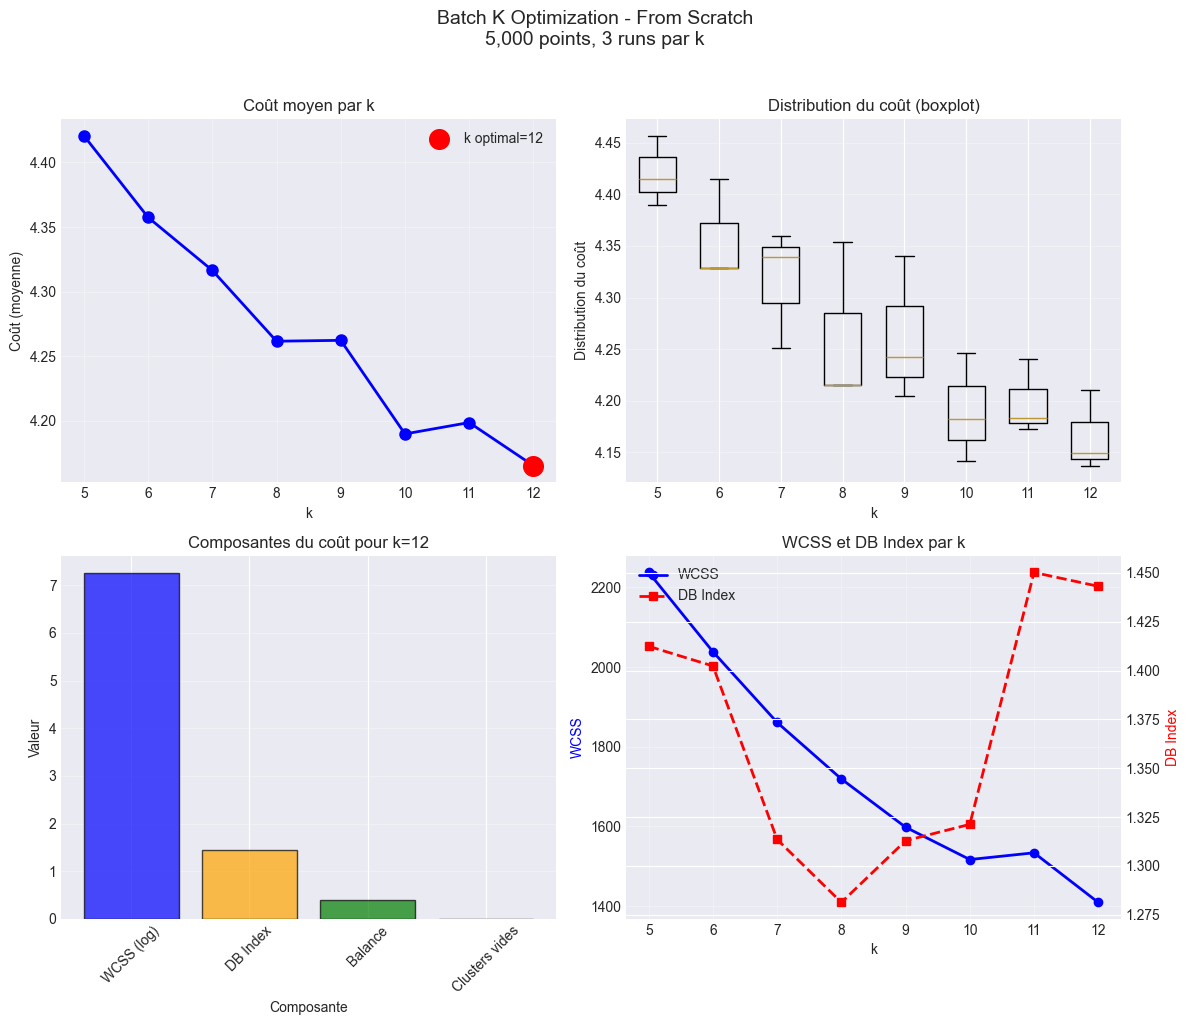


📊 RÉSULTATS BATCH OPTIMIZATION:
-------------------------------------------------------------------------------------
k     Coût moyen      Std        WCSS            DB Index        Balance   
-------------------------------------------------------------------------------------
5     4.4207          0.0277     2237.28         1.4124          0.5476    
6     4.3575          0.0407     2038.28         1.4023          0.4906    
7     4.3165          0.0473     1860.97         1.3135          0.4606    
8     4.2616          0.0653     1719.20         1.2813          0.5312    
9     4.2623          0.0573     1598.15         1.3129          0.6109    
10    4.1899          0.0434     1517.04         1.3213          0.4121    
11    4.1987          0.0297     1533.96         1.4502          0.3484    
12    4.1653          0.0319     1409.51         1.4431          0.3925    
-------------------------------------------------------------------------------------

🏆 MEILLEUR K TROUVÉ: 12


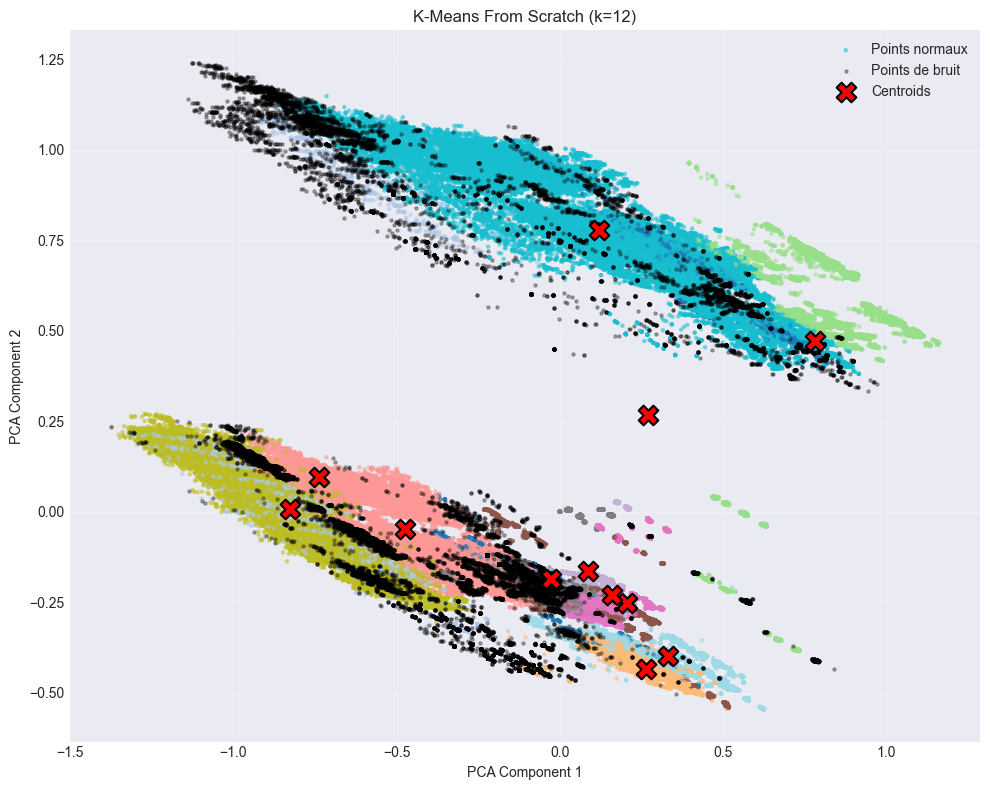

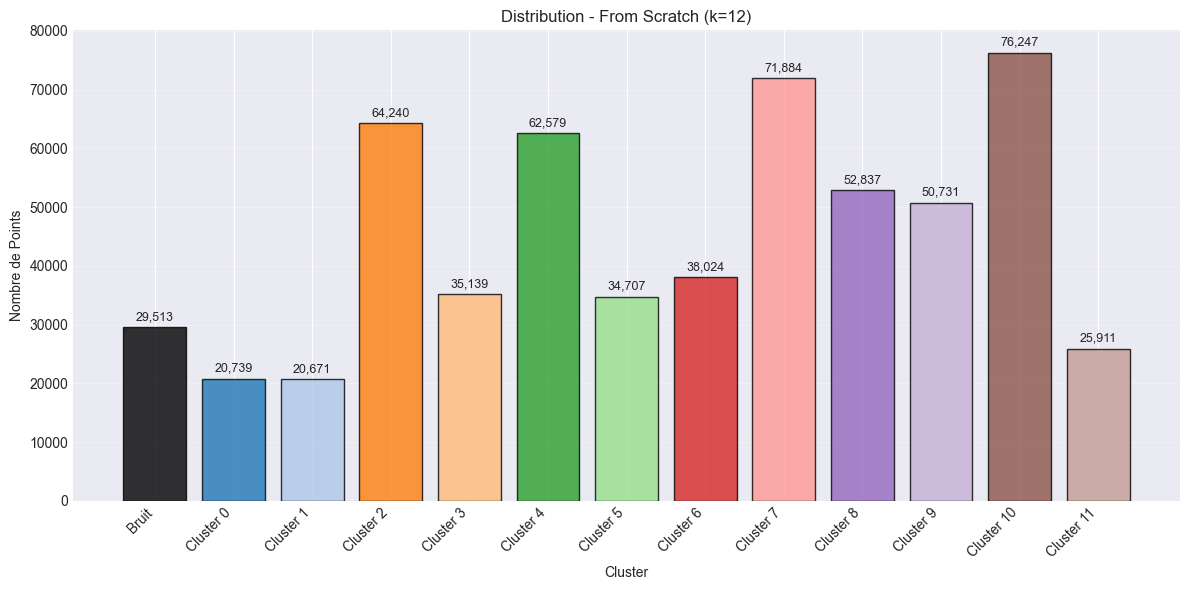

📊 STATISTIQUES CLUSTERS:
   Points de bruit: 29,513 (5.06%)
   Nombre de clusters: 12
   Points par cluster: min=20,671, max=76,247
   Ratio min/max: 27.11%

2️⃣  K-MEANS SCIKIT-LEARN (OPTIMISÉ)

🔍 ÉTAPE 1: Batch Optimization rapide (5-12)

🔢 BATCH K OPTIMIZATION - K-Means Scikit-Learn
🔍 Configuration Batch Optimization:
   • Dataset total: 583,222 points
   • Échantillon: 8,000 points
   • Plage k: 5-12 (8 valeurs)
   • Runs par k: 3
   • Métriques rapides: WCSS + DB + Balance

📊 Évaluation rapide des k...


Batch optimization: 100%|██████████| 8/8 [00:07<00:00,  1.07it/s]


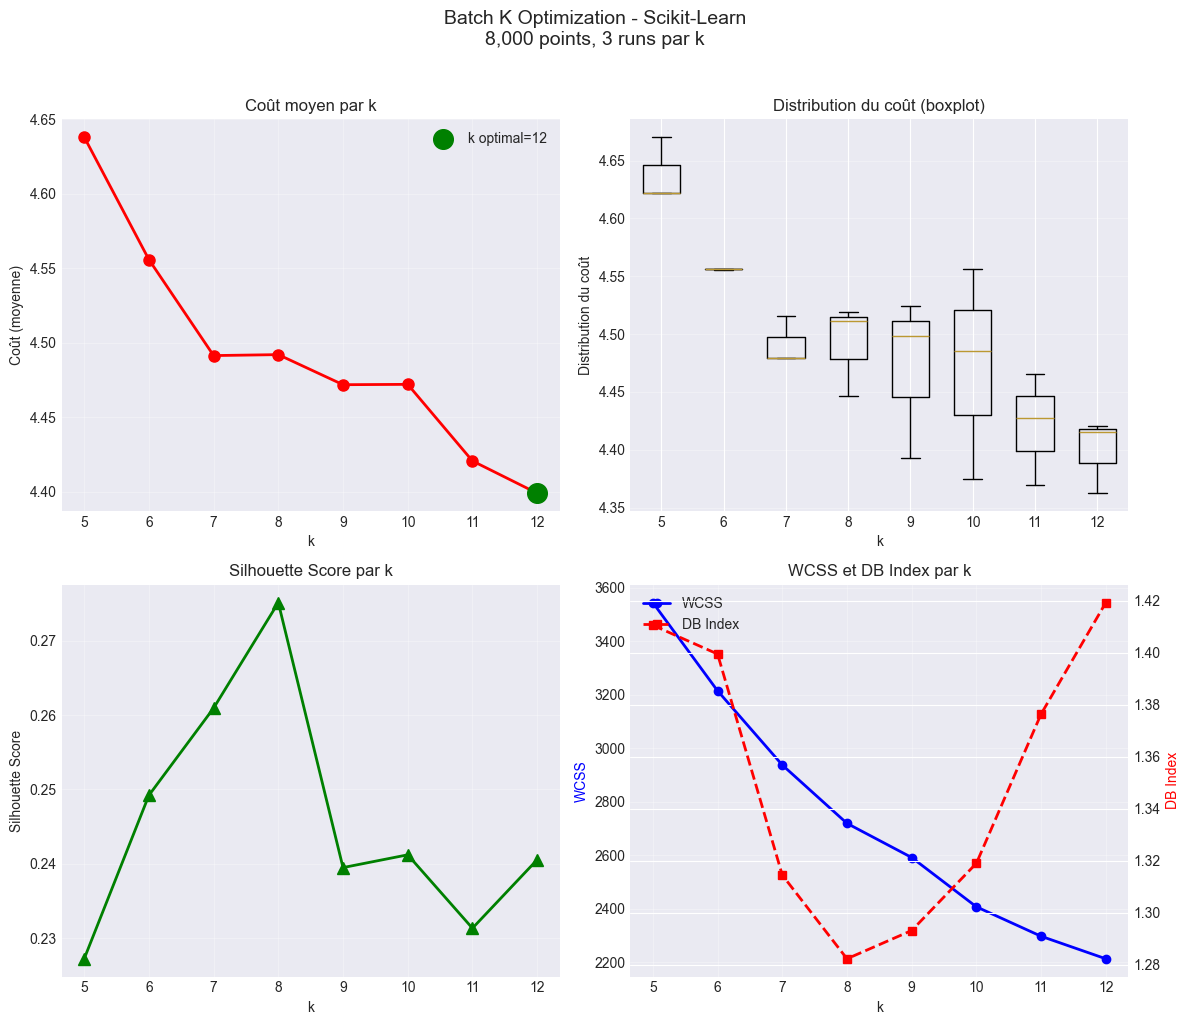


📊 RÉSULTATS BATCH OPTIMIZATION:
-------------------------------------------------------------------------------------
k     Coût moyen      Std        WCSS            DB Index        Balance   
-------------------------------------------------------------------------------------
5     4.6382          0.0228     3543.73         1.4106          0.5618    
6     4.5559          0.0001     3214.29         1.3995          0.4913    
7     4.4915          0.0168     2937.15         1.3144          0.4634    
8     4.4921          0.0326     2719.09         1.2822          0.5381    
9     4.4720          0.0570     2591.52         1.2931          0.3738    
10    4.4722          0.0749     2407.36         1.3190          0.4279    
11    4.4208          0.0393     2297.33         1.3764          0.4355    
12    4.3992          0.0261     2213.23         1.4193          0.4278    
-------------------------------------------------------------------------------------

🏆 MEILLEUR K TROUVÉ: 12


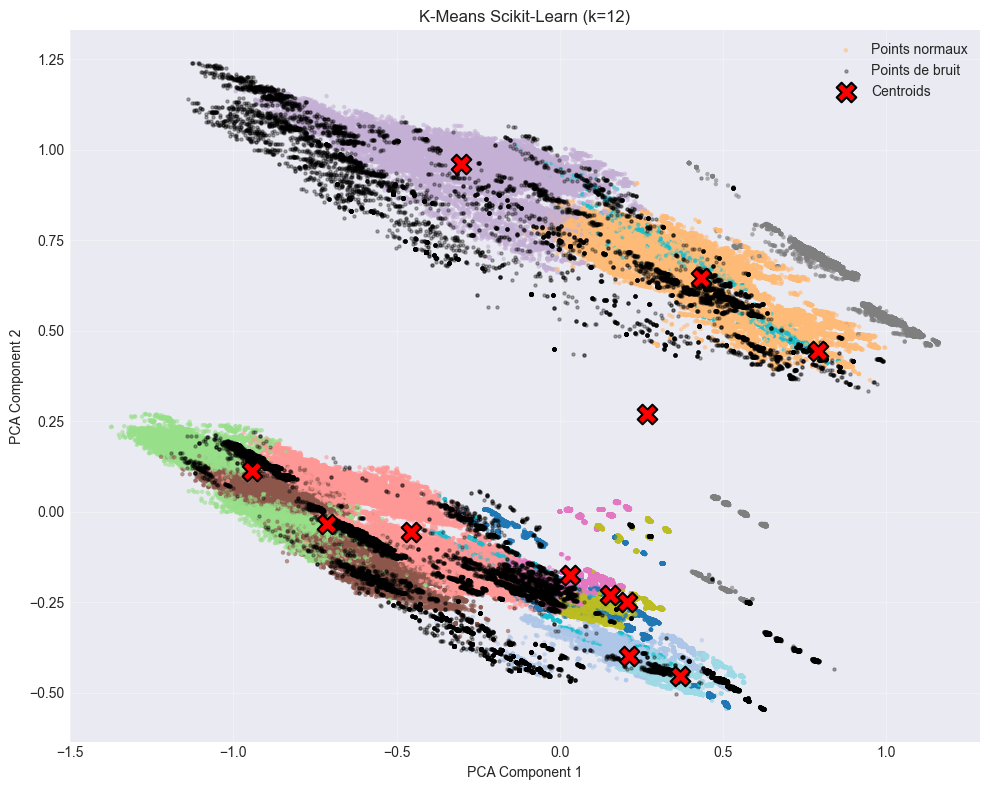

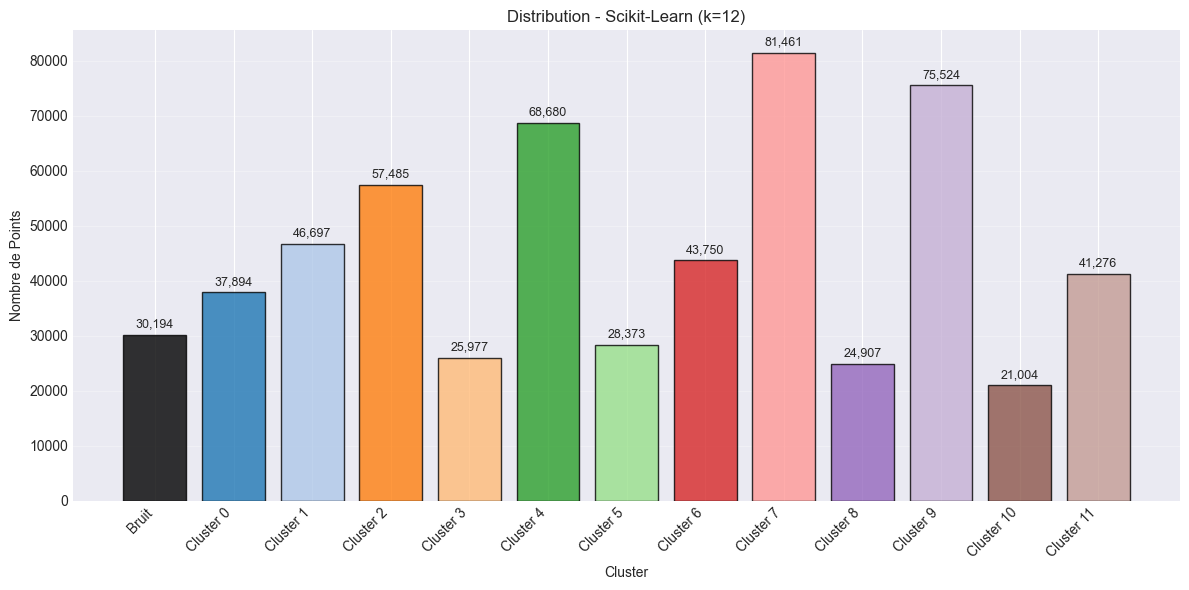

📊 STATISTIQUES CLUSTERS:
   Points de bruit: 30,194 (5.18%)
   Nombre de clusters: 12
   Points par cluster: min=21,004, max=81,461
   Ratio min/max: 25.78%

3️⃣  COMPARAISON DÉTAILLÉE

📊 COMPARAISON DES MÉTRIQUES:
-------------------------------------------------------------------------------------
Métrique                  From Scratch         Scikit-Learn         Différence      Meilleur  
-------------------------------------------------------------------------------------
WCSS                      174685.66            164675.32            10010.34        Sklearn   
Silhouette                0.2380               0.2479               0.0100          Sklearn   
Davies-Bouldin            1.4205               1.4402               0.0197          Scratch   
Calinski-Harabasz         99582.77             108859.18            9276.41         Sklearn   
Dunn Index                0.1677               0.1885               0.0208          Sklearn   
-------------------------------------------

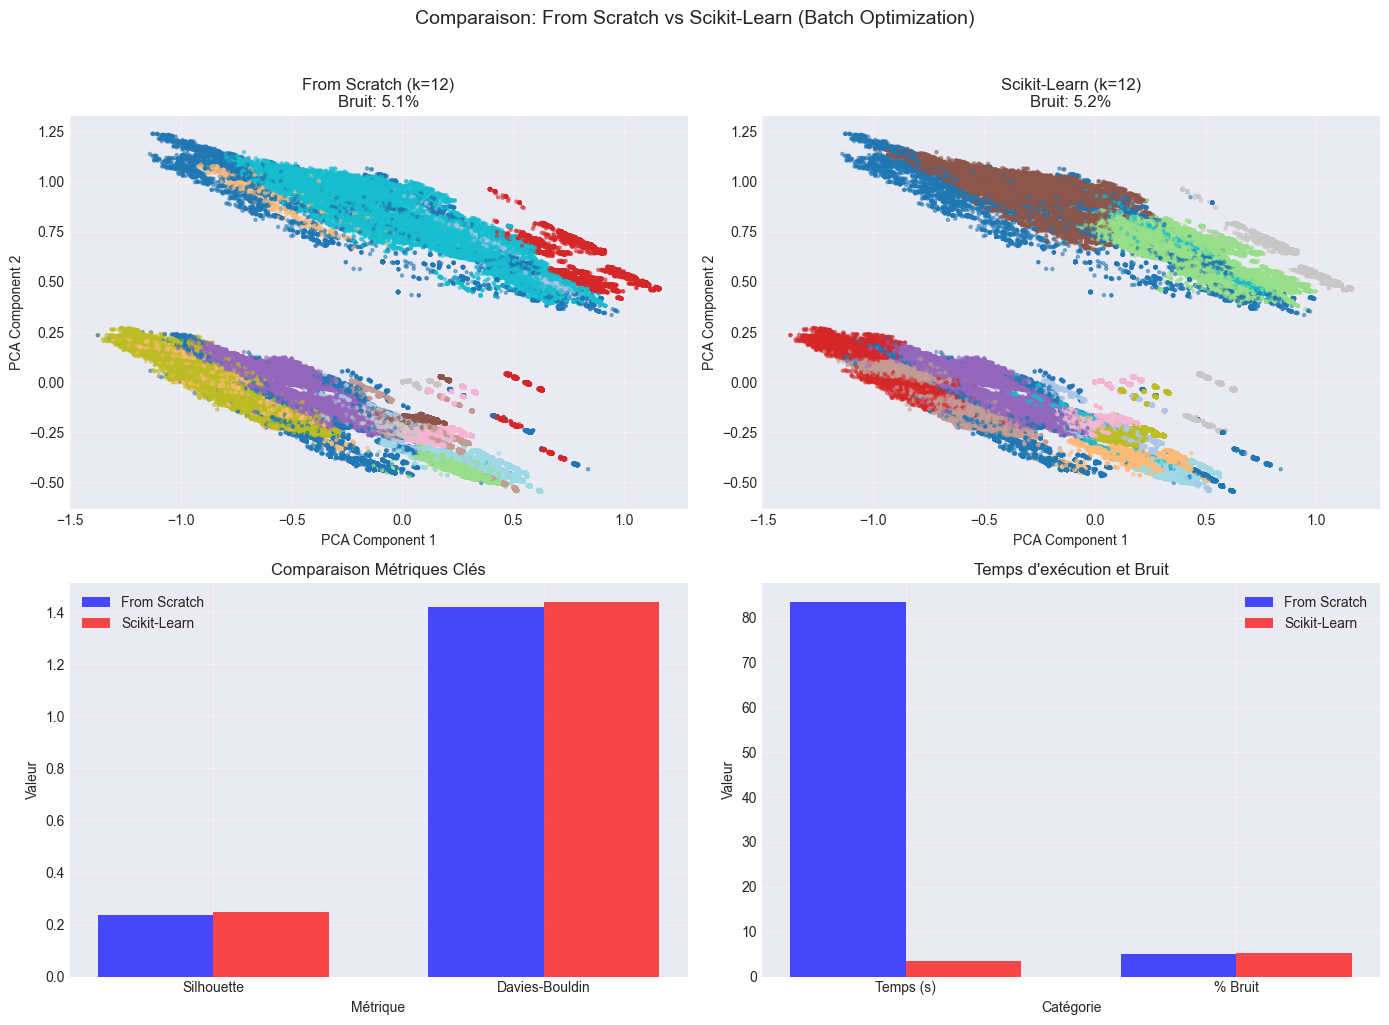


🔗 SIMILARITÉ ENTRE LES DEUX CLUSTERING:
   Adjusted Rand Index: 0.7028
   • 1.0 = clusters identiques
   • 0.0 = clusters indépendants
   ⚠️  Les clusters sont modérément similaires

💡 RECOMMANDATION FINALE:
   • Batch Optimization: test rapide sur échantillon (5-12)
   • Entraînement final: métriques complètes sur 100% du dataset
   • Différence silhouette: 0.0100
   • Gain de temps: 80.05s
   🏆 Scikit-Learn est meilleur en qualité (silhouette plus élevée)


In [9]:
# Exécution avec Batch Optimization
print("🚀 Lancement de l'analyse avec Batch Optimization...")
print("   Étape 1: Test rapide des k (5-12) sur échantillon")
print("   Étape 2: Entraînement final avec meilleur k sur 100% du dataset")
print("   Étape 3: Métriques complètes sur dataset complet")
print("   " + "="*60)

results = run_complete_analysis_batch()

## 10. 🔥 ANALYSE AVEC VARIABLE 'fire' (SI DISPONIBLE)


🔥 ANALYSE DES CLUSTERS PAR RAPPORT AUX FEUX

📊 K-MEANS SCRATCH - Analyse feux vs clusters:

📈 STATISTIQUES FEUX PAR CLUSTER (points normaux):
          feux  total  proportion  %_feux
cluster                                  
0           91  20739       0.004     0.4
1         2358  20671       0.114    11.4
2        24322  64240       0.379    37.9
3          984  35139       0.028     2.8
4         1457  62579       0.023     2.3
5        14534  34707       0.419    41.9
6           72  38024       0.002     0.2
7        18636  71884       0.259    25.9
8         5883  52837       0.111    11.1
9         4065  50731       0.080     8.0
10        1326  76247       0.017     1.7
11        8437  25911       0.326    32.6

📊 STATISTIQUES FEUX DANS LE BRUIT:
   • Points de bruit: 29,513
   • Feux dans le bruit: 1,106
   • % de feux dans le bruit: 3.7%


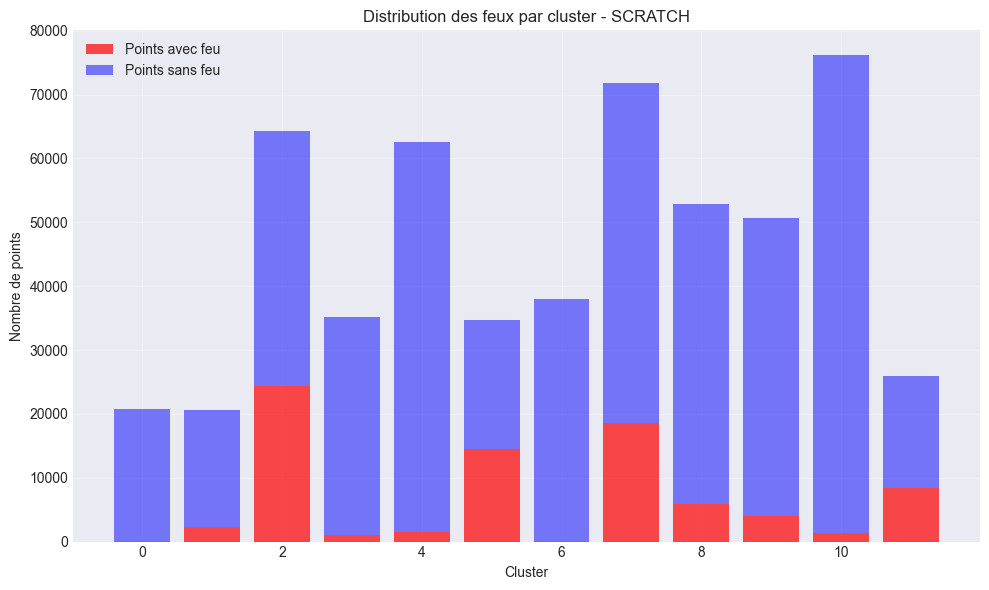


📊 K-MEANS SKLEARN - Analyse feux vs clusters:

📈 STATISTIQUES FEUX PAR CLUSTER (points normaux):
          feux  total  proportion  %_feux
cluster                                  
0           72  37894       0.002     0.2
1        17278  46697       0.370    37.0
2          743  57485       0.013     1.3
3         2574  25977       0.099     9.9
4         1470  68680       0.021     2.1
5          678  28373       0.024     2.4
6         3943  43750       0.090     9.0
7        19644  81461       0.241    24.1
8          887  24907       0.036     3.6
9        19409  75524       0.257    25.7
10          92  21004       0.004     0.4
11       15477  41276       0.375    37.5

📊 STATISTIQUES FEUX DANS LE BRUIT:
   • Points de bruit: 30,194
   • Feux dans le bruit: 1,004
   • % de feux dans le bruit: 3.3%


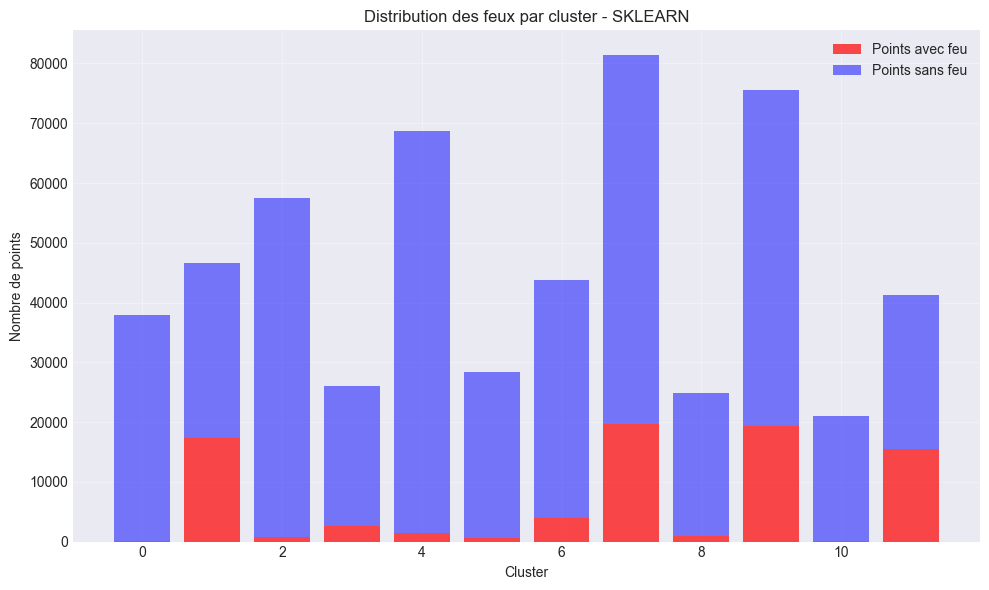

In [10]:
# Analyse avec la variable 'fire' si disponible
if y is not None and 'results' in locals():
    print("\n" + "="*80)
    print("🔥 ANALYSE DES CLUSTERS PAR RAPPORT AUX FEUX")
    print("="*80)
    
    for algo_name in ['scratch', 'sklearn']:
        if algo_name in results:
            print(f"\n📊 K-MEANS {algo_name.upper()} - Analyse feux vs clusters:")
            
            algo_data = results[algo_name]
            labels_with_noise = algo_data['labels_with_noise']
            noise_mask = algo_data['noise_mask']
            
            # Création DataFrame d'analyse
            analysis_df = pd.DataFrame({
                'cluster': labels_with_noise,
                'fire': y,
                'is_noise': noise_mask
            })
            
            # Séparer points normaux et bruit
            normal_points = analysis_df[analysis_df['cluster'] != -1]
            noise_points = analysis_df[analysis_df['cluster'] == -1]
            
            # Analyse points normaux
            if len(normal_points) > 0:
                cluster_fire_stats = normal_points.groupby('cluster').agg({
                    'fire': ['sum', 'count', 'mean']
                }).round(3)
                cluster_fire_stats.columns = ['feux', 'total', 'proportion']
                cluster_fire_stats['%_feux'] = (cluster_fire_stats['feux'] / cluster_fire_stats['total'] * 100).round(1)
                
                print(f"\n📈 STATISTIQUES FEUX PAR CLUSTER (points normaux):")
                print(cluster_fire_stats.to_string())
            
            # Analyse bruit
            if len(noise_points) > 0:
                print(f"\n📊 STATISTIQUES FEUX DANS LE BRUIT:")
                print(f"   • Points de bruit: {len(noise_points):,}")
                print(f"   • Feux dans le bruit: {noise_points['fire'].sum():,}")
                print(f"   • % de feux dans le bruit: {noise_points['fire'].sum()/len(noise_points)*100:.1f}%")
            
            # Graphique simple
            plt.figure(figsize=(10, 6))
            
            if len(normal_points) > 0:
                # Cluster avec plus/moins de feux
                cluster_fire_counts = normal_points.groupby('cluster')['fire'].sum()
                cluster_sizes = normal_points.groupby('cluster').size()
                
                plt.bar(cluster_fire_counts.index, cluster_fire_counts.values, 
                       color='red', alpha=0.7, label='Points avec feu')
                plt.bar(cluster_fire_counts.index, cluster_sizes.values - cluster_fire_counts.values,
                       bottom=cluster_fire_counts.values, color='blue', alpha=0.5, label='Points sans feu')
            
            plt.xlabel('Cluster')
            plt.ylabel('Nombre de points')
            plt.title(f'Distribution des feux par cluster - {algo_name.upper()}')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

## 11. 💾 SAUVEGARDE DES RÉSULTATS

In [11]:
# Sauvegarde des résultats
if 'results' in locals():
    from datetime import datetime
    import pickle
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    print("\n" + "="*80)
    print("💾 SAUVEGARDE DES RÉSULTATS")
    print("="*80)
    
    # 1. Sauvegarde CSV des labels
    labels_df = pd.DataFrame({
        'point_index': np.arange(len(X)),
        'cluster_scratch': results['scratch']['labels_with_noise'],
        'cluster_sklearn': results['sklearn']['labels_with_noise'],
        'is_noise_scratch': results['scratch']['noise_mask'],
        'is_noise_sklearn': results['sklearn']['noise_mask']
    })
    
    if y is not None:
        labels_df['fire'] = y
    
    labels_file = f'kmeans_results_batch_{timestamp}.csv'
    labels_df.to_csv(labels_file, index=False)
    print(f"✅ Labels sauvegardés: {labels_file}")
    print(f"   • {len(labels_df):,} lignes")
    
    # 2. Sauvegarde des métriques
    metrics_summary = pd.DataFrame({
        'Algorithm': ['From Scratch (Basique)', 'Scikit-Learn (Optimisé)'],
        'k': [results['scratch']['k'], results['sklearn']['k']],
        'Training_Time_s': [results['scratch']['time'], results['sklearn']['time']],
        'WCSS': [results['scratch']['metrics']['wcss'], results['sklearn']['metrics']['wcss']],
        'Silhouette': [results['scratch']['metrics']['silhouette'], results['sklearn']['metrics']['silhouette']],
        'Davies_Bouldin': [results['scratch']['metrics']['davies_bouldin'], results['sklearn']['metrics']['davies_bouldin']],
        'Calinski_Harabasz': [results['scratch']['metrics']['calinski_harabasz'], results['sklearn']['metrics']['calinski_harabasz']],
        'Dunn_Index': [results['scratch']['metrics']['dunn_index'], results['sklearn']['metrics']['dunn_index']],
        'Noise_Points': [results['scratch']['noise_stats']['n_noise_points'], 
                        results['sklearn']['noise_stats']['n_noise_points']],
        'Noise_Percentage': [results['scratch']['noise_stats']['noise_percentage'], 
                            results['sklearn']['noise_stats']['noise_percentage']]
    })
    
    metrics_file = f'kmeans_metrics_batch_{timestamp}.csv'
    metrics_summary.to_csv(metrics_file, index=False)
    print(f"✅ Métriques sauvegardées: {metrics_file}")
    
    # 3. Rapport simple
    report_file = f'kmeans_report_batch_{timestamp}.txt'
    with open(report_file, 'w') as f:
        f.write("="*60 + "\n")
        f.write("RAPPORT K-MEANS - FROM SCRATCH vs SCIKIT-LEARN (BATCH OPTIMIZATION)\n")
        f.write("="*60 + "\n\n")
        
        f.write("STRATÉGIE:\n")
        f.write("1. Batch Optimization rapide sur échantillon (k: 5-12)\n")
        f.write("2. Entraînement final avec meilleur k sur 100% du dataset\n")
        f.write("3. Métriques complètes calculées uniquement sur entraînement final\n\n")
        
        f.write("COMPARAISON:\n")
        f.write(f"From Scratch (Basique): k={results['scratch']['k']}, silhouette={results['scratch']['metrics']['silhouette']:.4f}, bruit={results['scratch']['noise_stats']['noise_percentage']:.1f}%\n")
        f.write(f"Scikit-Learn (Optimisé): k={results['sklearn']['k']}, silhouette={results['sklearn']['metrics']['silhouette']:.4f}, bruit={results['sklearn']['noise_stats']['noise_percentage']:.1f}%\n\n")
        
        f.write("DIFFÉRENCE:\n")
        f.write(f"Silhouette: {results['sklearn']['metrics']['silhouette'] - results['scratch']['metrics']['silhouette']:.4f}\n")
        f.write(f"Temps: {results['scratch']['time'] - results['sklearn']['time']:.2f}s\n")
        f.write(f"Bruit: {results['sklearn']['noise_stats']['noise_percentage'] - results['scratch']['noise_stats']['noise_percentage']:.1f}%\n")
    
    print(f"✅ Rapport généré: {report_file}")
    
    print(f"\n🎉 ANALYSE TERMINÉE AVEC SUCCÈS !")
    print(f"📊 Fichiers générés:")
    print(f"   1. {labels_file} - Labels des clusters")
    print(f"   2. {metrics_file} - Métriques de performance")
    print(f"   3. {report_file} - Rapport de synthèse")

print("\n" + "="*80)
print("✅ ANALYSE K-MEANS COMPLÈTEMENT TERMINÉE !")
print("✅ Batch Optimization (k: 5-12) + Évaluation finale complète")
print("="*80)


💾 SAUVEGARDE DES RÉSULTATS
✅ Labels sauvegardés: kmeans_results_batch_20260106_195801.csv
   • 583,222 lignes
✅ Métriques sauvegardées: kmeans_metrics_batch_20260106_195801.csv
✅ Rapport généré: kmeans_report_batch_20260106_195801.txt

🎉 ANALYSE TERMINÉE AVEC SUCCÈS !
📊 Fichiers générés:
   1. kmeans_results_batch_20260106_195801.csv - Labels des clusters
   2. kmeans_metrics_batch_20260106_195801.csv - Métriques de performance
   3. kmeans_report_batch_20260106_195801.txt - Rapport de synthèse

✅ ANALYSE K-MEANS COMPLÈTEMENT TERMINÉE !
✅ Batch Optimization (k: 5-12) + Évaluation finale complète
